# PenDoc: Handwritten Character & Word Recognition

This notebook trains and evaluates the recognition models behind PenDoc's OCR
pipeline, in two parallel approaches:

**1. Character-level classification.** We train two fine-tuned models, a ResNet18 CNN and a DeiT-Tiny vision transformer, to classify individual characters. We blend the softmax outputs into a weighted ensemble, with the blend weight tuned on the validation split.

**2. Word-level recognition.** We also train a CNN combined with Bidirectional LSTM with Connectionist Temporal Classification loss to read a full word image directly, learning the image-to-character alignment on its own, without segmenting individual letters.

**Pipeline**
1. **Datasets**:

- `handwritten-letters` Used to train and test the individual character classification ensemble models
- `handwritten-words` Used to train and test the full word image-to-character alignment
2. **ResNet18**: A convolutional network pretrained on ImageNet, fine-tuned here for single-letter classification. The stem and first residual block stay frozen, as to not unlearn already captured general low-level edge/texture features. The deeper residual blocks and a newly attached classification head are trained on the letter crops. The model is optimized with Adam and a OneCycle learning-rate schedule with early stopping on validation loss to reduce overfitting.
3. **DeiT-Tiny**: A compact vision transformer pretrained on ImageNet and fine-tuned the same way as ResNet18. This model is an architecturally different, as it performs self-attention over image patches instead of convolutional filters. The patch embedding and the first half of the transformer blocks are frozen for the same purpose as the ResNet model.
4. **Ensemble**: A simple weighted average of the two model softmax probability outputs. The blend weight is swept over the validation split and the best-performing value is applied to the test set.
5. **CRNN Word Recognition (CTC)**: CRNN is a convolutional feature extractor feeds a two-layer bidirectional LSTM that reads the resulting feature map left to right, followed by a linear layer producing per-timestep character probabilities. The model is trained with Connectionist Temporal Classification(CTC) loss, which lets the model learn the alignment between image columns and output characters directly from (image, label) pairs.
6. **End-to-End Evaluation**: Run the trained CRNN on the test set and
   report word accuracy and character error rate (CER).

# Set-Up: Installs, Imports, and Dataset Loading

In [ ]:
# Install kaggle, opencv, Pillow, timm (for DeiT), and jiwer (for character error rate)
!pip install -q kaggle opencv-python Pillow timm jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 62.8 MB/s eta 0:00:00


In [ ]:
# Standard library
import os
import shutil
from pathlib import Path

# Data handling
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split as tts
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Image processing
from PIL import Image
import cv2

# PyTorch
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet18, ResNet18_Weights
from torch.optim.lr_scheduler import OneCycleLR
from tqdm import tqdm

# DeiT-Tiny model
import timm

# Evaluation (character error rate for the CRNN section)
import jiwer

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
# Authenticate with Kaggle API using kaggle.json
KAGGLE_JSON_PATH = "/content/kaggle.json"

os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
shutil.copy(KAGGLE_JSON_PATH, os.path.expanduser("~/.kaggle/kaggle.json"))
os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)

# Import kaggle
import kaggle

In [ ]:
# Download the character-level dataset: individual handwritten letters used to train ensemble character models
!kaggle datasets download -d warrenxnguyen/handwritten-letters --force
!unzip -q -o handwritten-letters.zip -d /content

Dataset URL: https://www.kaggle.com/datasets/warrenxnguyen/handwritten-letters
License(s): unknown
100% 427M/427M [00:07<00:00, 58.7MB/s]



In [ ]:
# Download the word-level dataset: full handwritten words used to train CRNN model
!kaggle datasets download -d warrenxnguyen/handwritten-words --force
!unzip -q -o handwritten-words.zip -d /content


Dataset URL: https://www.kaggle.com/datasets/warrenxnguyen/handwritten-words
License(s): unknown
100% 1.26G/1.26G [00:21<00:00, 61.8MB/s]



## ResNet18

Fine-tunes a pretrained ResNet18 on individually segmented handwritten letter images. The stem and first residual block are frozen and only the deeper layers plus a new classification head are trained, using a OneCycle learning-rate schedule and early stopping on validation loss.

In [6]:
# Training hyperparameter constants shared by both image classifiers (ResNet18 and DeiT-Tiny)
RANDOM_SEED = 123
NUM_EPOCHS = 20
TRAIN_RATIO, VAL_RATIO, TEST_RATIO = 0.8, 0.1, 0.1
LEARNING_RATE = 3e-4
ONE_CYCLE_PCT_START = 0.3
EARLY_STOP_PATIENCE = 5
BATCH_SIZE = 128
USE_PRETRAINED_WEIGHTS = True

# Collect all letter image paths, one subfolder per class
LETTER_IMAGE_DIR = Path("/content/Handwritten-Letters")
LETTER_IMAGE_PATHS = list(LETTER_IMAGE_DIR.glob("*/*.jpg"))

# Dataset class: loads a letter image, applies transforms, returns (image, label)
class LetterImageDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, label_to_index: dict, image_transforms=None):
        """Store image paths, map string labels to integer class indices, and stash the transform pipeline."""
        self.image_paths = dataframe["Image"].tolist()
        self.labels = dataframe["Target"].map(label_to_index).tolist()
        self.image_transforms = image_transforms

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        """Load one letter image, apply the model-specific transform, and return it with its label."""
        image = Image.open(self.image_paths[idx]).convert("RGB")
        if self.image_transforms:
            image = self.image_transforms(image)
        return image, self.labels[idx]

# EarlyStopping class: saves the best checkpoint, stops after N epochs with no improvement
class EarlyStopping:
    def __init__(self, patience=EARLY_STOP_PATIENCE, min_delta=1e-5, checkpoint_path="best_model.pth"):
        """Configure how many non-improving epochs to tolerate and where to save the best checkpoint."""
        self.patience = patience
        self.min_delta = min_delta
        self.checkpoint_path = checkpoint_path
        self.best_loss = None
        self.early_stop = False
        self.epochs_since_improvement = 0

    def __call__(self, val_loss, model):
        """Check this epoch's validation loss against the best seen so far."""
        if self.best_loss is None or val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self._save_checkpoint(model)
            self.epochs_since_improvement = 0
        else:
            self.epochs_since_improvement += 1
            if self.epochs_since_improvement >= self.patience:
                self.early_stop = True

    def _save_checkpoint(self, model):
        """Persist the current model weights to disk as the best checkpoint seen so far."""
        torch.save(model.state_dict(), self.checkpoint_path)


def train_epoch_classifier(model, dataloader, loss_fn, optimizer, scheduler=None):
    """Runs one training epoch over an image classifier and returns average loss/accuracy."""
    model.train()
    total_loss, total_accuracy = 0, 0

    for images, labels in dataloader:
        images, labels = images.to(DEVICE, torch.float32), labels.to(DEVICE, torch.long)

        optimizer.zero_grad()
        predictions = model(images)
        loss = loss_fn(predictions, labels)
        loss.backward()
        optimizer.step()
        if scheduler:
            scheduler.step()

        total_loss += loss.item()
        total_accuracy += accuracy_score(labels.cpu(), predictions.argmax(dim=1).cpu())

    return total_loss / len(dataloader), total_accuracy / len(dataloader)


def evaluate_epoch_classifier(model, dataloader, loss_fn):
    """Runs one validation pass over an image classifier, with no gradient updates."""
    model.eval()
    total_loss = 0
    all_predictions, all_labels = [], []

    with torch.inference_mode():
        for images, labels in dataloader:
            images, labels = images.to(DEVICE, torch.float32), labels.to(DEVICE, torch.long)
            predictions = model(images)
            total_loss += loss_fn(predictions, labels).item()
            all_predictions.extend(predictions.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / len(dataloader), accuracy_score(all_labels, all_predictions)

# Train with Adam optimizer & OneCycle LR schedule, tracking val loss for early stopping
def train_classifier(model, train_dataloader, val_dataloader, loss_fn, optimizer, scheduler, early_stopping, epochs=NUM_EPOCHS):
    """Trains an image classifier for up to `epochs`, stopping early if validation loss plateaus."""
    history = {"train_loss": [], "train_accuracy": [], "val_loss": [], "val_accuracy": []}

    for epoch in tqdm(range(epochs), desc="Training"):
        train_loss, train_accuracy = train_epoch_classifier(model, train_dataloader, loss_fn, optimizer, scheduler)
        val_loss, val_accuracy = evaluate_epoch_classifier(model, val_dataloader, loss_fn)

        print(f"Epoch {epoch+1}: "f"Train Loss {train_loss:.4f}, Train Acc {train_accuracy:.4f}, "f"Val Loss {val_loss:.4f}, Val Acc {val_accuracy:.4f}")

        early_stopping(val_loss, model)
        if early_stopping.early_stop:
            print("Early stopping triggered.")
            break

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_accuracy)

    return history


def plot_training_curves(history, title_prefix=""):
    """Plots loss and accuracy curves, train vs. validation, side by side."""
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))

    ax[0].plot(history["train_loss"], label="Train", color="red")
    ax[0].plot(history["val_loss"], label="Valid", color="blue")
    ax[0].set_title(f"{title_prefix}Loss"), ax[0].set_xlabel("Epoch"), ax[0].set_ylabel("Loss")
    ax[0].legend()

    ax[1].plot(history["train_accuracy"], label="Train", color="red")
    ax[1].plot(history["val_accuracy"], label="Valid", color="blue")
    ax[1].set_title(f"{title_prefix}Accuracy"), ax[1].set_xlabel("Epoch"), ax[1].set_ylabel("Accuracy")
    ax[1].legend()

    plt.tight_layout()
    plt.show()


def predict_probabilities(model, dataloader, desc="Inference"):
    """Runs inference over a dataloader and returns per-class softmax probabilities."""
    model.eval()
    all_probabilities = []
    with torch.inference_mode():
        for images, _ in tqdm(dataloader, desc=desc):
            images = images.to(DEVICE, torch.float32)
            probabilities = torch.softmax(model(images), dim=1)
            all_probabilities.append(probabilities.cpu().numpy())
    return np.concatenate(all_probabilities, axis=0)

# Reload the best saved checkpoint weights after training
def load_checkpoint(model, path):
    """Reloads a checkpoint saved during training (early stopping doesn't auto-restore in PyTorch)."""
    model.load_state_dict(torch.load(path, map_location=DEVICE))
    model.to(DEVICE).eval()
    return model

# Compute test accuracy, classification report, and confusion matrix
def evaluate_and_report(y_true, y_pred, class_names, title):
    """Prints accuracy + classification report and plots a confusion matrix heatmap."""
    accuracy = accuracy_score(y_true, y_pred)
    print(f"Test Accuracy = {accuracy:.4f}")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(9, 9))
    sns.heatmap(cm, cmap="Reds", annot=True, fmt=" ", cbar=False, square=True, linewidths=0.4, xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_ylabel("True", fontsize=12, fontweight="bold", color="darkblue")
    ax.set_xlabel("Predicted", fontsize=12, fontweight="bold", color="darkblue")
    ax.set_title(title, fontsize=14, fontweight="bold", color="black")
    fig.tight_layout()
    plt.show()
    return accuracy


# Build the letter-level dataset: one row per image, labeled by its subfolder name
letter_classes = sorted(os.listdir(LETTER_IMAGE_DIR))
letter_labels = [path.parent.stem for path in LETTER_IMAGE_PATHS]
letter_data = pd.DataFrame({"Image": LETTER_IMAGE_PATHS, "Target": letter_labels})

# Hold out 5% as an unused scrap split, then split the remainder into train/val/test
_, letter_data_kept = tts(letter_data, test_size=0.05, stratify=letter_data["Target"], random_state=RANDOM_SEED)
letter_train_df, letter_rest_df = tts(letter_data_kept, test_size=VAL_RATIO + TEST_RATIO, stratify=letter_data_kept["Target"], random_state=RANDOM_SEED)
letter_val_df, letter_test_df = tts(letter_rest_df, test_size=TEST_RATIO / (TEST_RATIO + VAL_RATIO), stratify=letter_rest_df["Target"], random_state=RANDOM_SEED)

label_to_index = {label: idx for idx, label in enumerate(letter_classes)}
y_test_true = letter_test_df["Target"].map(label_to_index).to_numpy()
y_val_true = letter_val_df["Target"].map(label_to_index).to_numpy()
num_workers = os.cpu_count()

# Load pretrained ResNet18: freeze stem & first residual block; fine-tune the rest
resnet_weights = ResNet18_Weights.DEFAULT
resnet_transforms = resnet_weights.transforms()

resnet_train_dataset = LetterImageDataset(letter_train_df, label_to_index, resnet_transforms)
resnet_val_dataset = LetterImageDataset(letter_val_df, label_to_index, resnet_transforms)
resnet_test_dataset = LetterImageDataset(letter_test_df, label_to_index, resnet_transforms)

resnet_train_loader = DataLoader(resnet_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=num_workers)
resnet_val_loader = DataLoader(resnet_val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers)
resnet_test_loader = DataLoader(resnet_test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers)

resnet_model = resnet18(weights=resnet_weights if USE_PRETRAINED_WEIGHTS else None)

# Freeze the stem and first residual block, only fine-tune the deeper layers
for name, param in resnet_model.named_parameters():
    if name.startswith("conv1") or name.startswith("bn1") or name.startswith("layer1"):
        param.requires_grad = False

# Swap in a classification head sized for our letter classes
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, len(letter_classes))
resnet_model.to(DEVICE)

resnet_loss_fn = nn.CrossEntropyLoss()
resnet_optimizer = optim.Adam(resnet_model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
resnet_early_stopping = EarlyStopping(patience=EARLY_STOP_PATIENCE, min_delta=0.0, checkpoint_path="best_resnet.pth")

torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)

resnet_scheduler = OneCycleLR(resnet_optimizer, max_lr=LEARNING_RATE, total_steps=len(resnet_train_loader) * NUM_EPOCHS, pct_start=ONE_CYCLE_PCT_START)

resnet_history = train_classifier(resnet_model, resnet_train_loader, resnet_val_loader, resnet_loss_fn, resnet_optimizer, resnet_scheduler, resnet_early_stopping, NUM_EPOCHS)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 118MB/s]
Training:   5%|▌         | 1/20 [01:01<19:19, 61.01s/it]

Epoch 1: Train Loss 1.8980, Train Acc 0.5155, Val Loss 0.8847, Val Acc 0.7931


Training:  10%|█         | 2/20 [01:53<16:44, 55.79s/it]

Epoch 2: Train Loss 0.4909, Train Acc 0.8931, Val Loss 0.2797, Val Acc 0.9300


...

Epoch 11: Train Loss 0.0109, Train Acc 0.9969, Val Loss 0.1509, Val Acc 0.9653


Training:  60%|██████    | 12/20 [10:49<07:10, 53.81s/it]

Epoch 12: Train Loss 0.0049, Train Acc 0.9987, Val Loss 0.1590, Val Acc 0.9623


Training:  60%|██████    | 12/20 [11:43<07:48, 58.61s/it]

Epoch 13: Train Loss 0.0041, Train Acc 0.9987, Val Loss 0.1567, Val Acc 0.9667
Early stopping triggered.


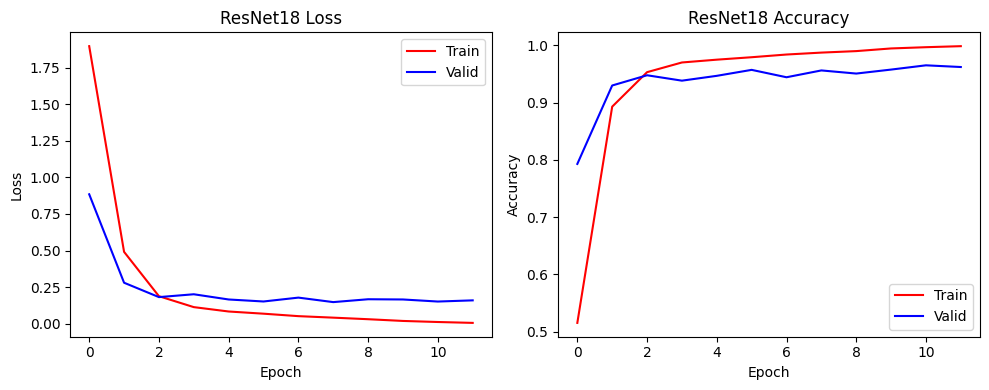

ResNet18 inference: 100%|██████████| 16/16 [00:05<00:00,  2.94it/s]


Test Accuracy = 0.9469
              precision    recall  f1-score   support

           A     0.9239    0.9659    0.9444        88
           B     0.9773    0.9556    0.9663        45
           C     0.9403    0.9130    0.9265        69
           D     0.9259    0.9494    0.9375        79
           E     0.9375    1.0000    0.9677       165
           F     1.0000    0.9500    0.9744        60
           G     0.8621    0.8621    0.8621        29
           H     1.0000    0.9683    0.9839        63
           I     0.6562    0.8873    0.7545        71
           J     0.9500    0.8636    0.9048        22
           K     0.9565    0.9565    0.9565        23
           L     0.8525    0.6047    0.7075        86
           M     0.9524    0.9836    0.9677        61
           N     0.9811    0.9541    0.9674       109
           O     0.9939    0.9878    0.9909       329
           P     0.9825    1.0000    0.9912        56
           Q     0.8750    0.8400    0.8571        25
    

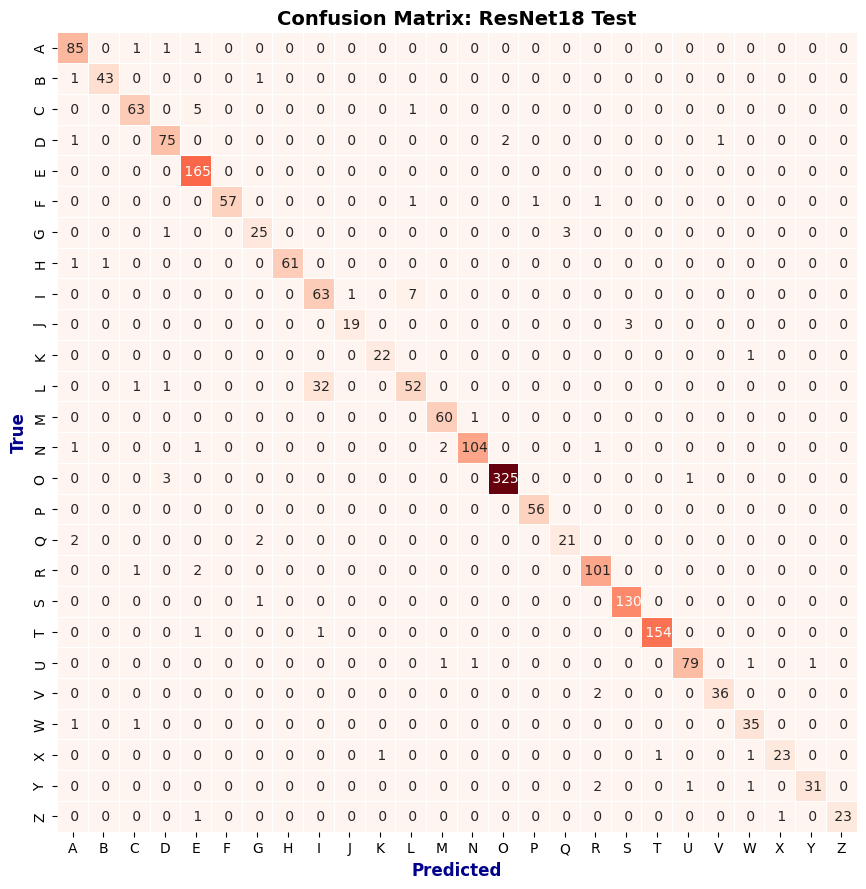

In [7]:
# Reload the best saved checkpoint weights after training
resnet_model = load_checkpoint(resnet_model, "best_resnet.pth")

# Plot training/validation loss and accuracy curves
plot_training_curves(resnet_history, title_prefix="ResNet18 ")

# Run inference on the test set, get predicted probabilities and predicted classes
resnet_test_probabilities = predict_probabilities(resnet_model, resnet_test_loader, desc="ResNet18 inference")
resnet_test_predictions = np.argmax(resnet_test_probabilities, axis=1)

# Compute test accuracy, classification report, and confusion matrix
resnet_test_accuracy = evaluate_and_report(y_test_true, resnet_test_predictions, letter_classes, "Confusion Matrix: ResNet18 Test")

## DeiT-Tiny

Fine-tunes a pretrained DeiT-Tiny vision transformer on the same letter-classification task,as a point of comparison against the ResNet18 CNN. As with ResNet18, the early layers are frozen and only the later layers plus
a new classification head are trained.

In [ ]:
# Load pretrained DeiT-Tiny with a new classification head sized to the letter classes
deit_model = timm.create_model("deit_tiny_patch16_224", pretrained=USE_PRETRAINED_WEIGHTS, num_classes=len(letter_classes))

# Build DeiT's expected input transforms (its own size/normalization) from the model config
deit_data_config = timm.data.resolve_data_config({}, model=deit_model)
deit_transforms = timm.data.create_transform(**deit_data_config)

deit_train_dataset = LetterImageDataset(letter_train_df, label_to_index, deit_transforms)
deit_val_dataset = LetterImageDataset(letter_val_df, label_to_index, deit_transforms)
deit_test_dataset = LetterImageDataset(letter_test_df, label_to_index, deit_transforms)

deit_train_loader = DataLoader(deit_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=num_workers)
deit_val_loader = DataLoader(deit_val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers)
deit_test_loader = DataLoader(deit_test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers)

# Freeze patch embedding and first half of transformer blocks, fine-tune the rest
for param in deit_model.patch_embed.parameters():
    param.requires_grad = False
for i, block in enumerate(deit_model.blocks):
    if i < len(deit_model.blocks) // 2:
        for param in block.parameters():
            param.requires_grad = False

deit_model.to(DEVICE)

# Same training loop, optimizer, scheduler, early stopping setup as ResNet18
deit_loss_fn = nn.CrossEntropyLoss()
deit_optimizer = optim.Adam(deit_model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
deit_early_stopping = EarlyStopping(patience=EARLY_STOP_PATIENCE, min_delta=0.0, checkpoint_path="best_deit.pth")

deit_scheduler = OneCycleLR(deit_optimizer, max_lr=LEARNING_RATE, total_steps=len(deit_train_loader) * NUM_EPOCHS, pct_start=ONE_CYCLE_PCT_START)

deit_history = train_classifier(deit_model, deit_train_loader, deit_val_loader, deit_loss_fn, deit_optimizer, deit_scheduler, deit_early_stopping, NUM_EPOCHS)

Training:   5%|▌         | 1/20 [01:16<24:15, 76.62s/it]

Epoch 1: Train Loss 2.3228, Train Acc 0.3866, Val Loss 1.2810, Val Acc 0.6913


Training:  10%|█         | 2/20 [02:22<21:01, 70.07s/it]

Epoch 2: Train Loss 0.7746, Train Acc 0.8065, Val Loss 0.5056, Val Acc 0.8521


Training:  15%|█▌        | 3/20 [03:27<19:11, 67.76s/it]

...

Epoch 15: Train Loss 0.0040, Train Acc 0.9993, Val Loss 0.1975, Val Acc 0.9553


Training:  80%|████████  | 16/20 [17:26<04:17, 64.37s/it]

Epoch 16: Train Loss 0.0022, Train Acc 0.9999, Val Loss 0.1969, Val Acc 0.9558


Training:  80%|████████  | 16/20 [18:32<04:38, 69.53s/it]

Epoch 17: Train Loss 0.0016, Train Acc 1.0000, Val Loss 0.2017, Val Acc 0.9573
Early stopping triggered.


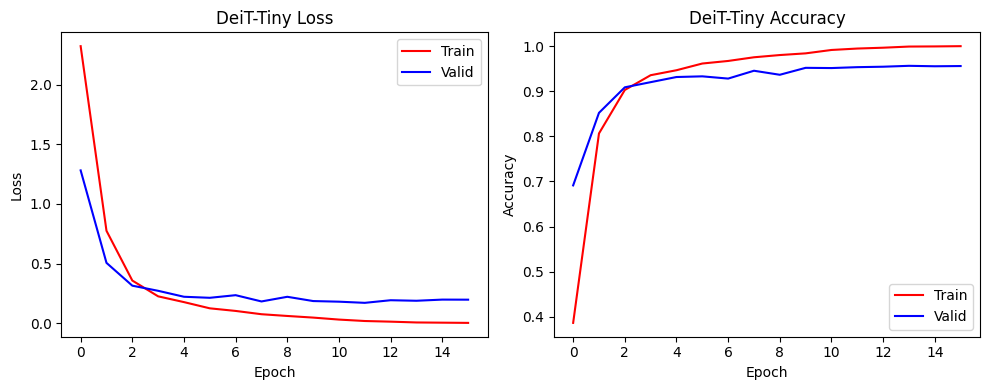

DeiT-Tiny inference: 100%|██████████| 16/16 [00:04<00:00,  3.37it/s]


Test Accuracy = 0.9459
              precision    recall  f1-score   support

           A     0.9451    0.9773    0.9609        88
           B     0.9556    0.9556    0.9556        45
           C     0.9265    0.9130    0.9197        69
           D     0.9259    0.9494    0.9375        79
           E     0.9586    0.9818    0.9701       165
           F     0.9667    0.9667    0.9667        60
           G     0.8800    0.7586    0.8148        29
           H     0.9683    0.9683    0.9683        63
           I     0.7108    0.8310    0.7662        71
           J     0.9545    0.9545    0.9545        22
           K     1.0000    0.8696    0.9302        23
           L     0.8286    0.6744    0.7436        86
           M     0.9833    0.9672    0.9752        61
           N     0.9725    0.9725    0.9725       109
           O     0.9908    0.9818    0.9863       329
           P     0.9818    0.9643    0.9730        56
           Q     0.8000    0.8000    0.8000        25
    

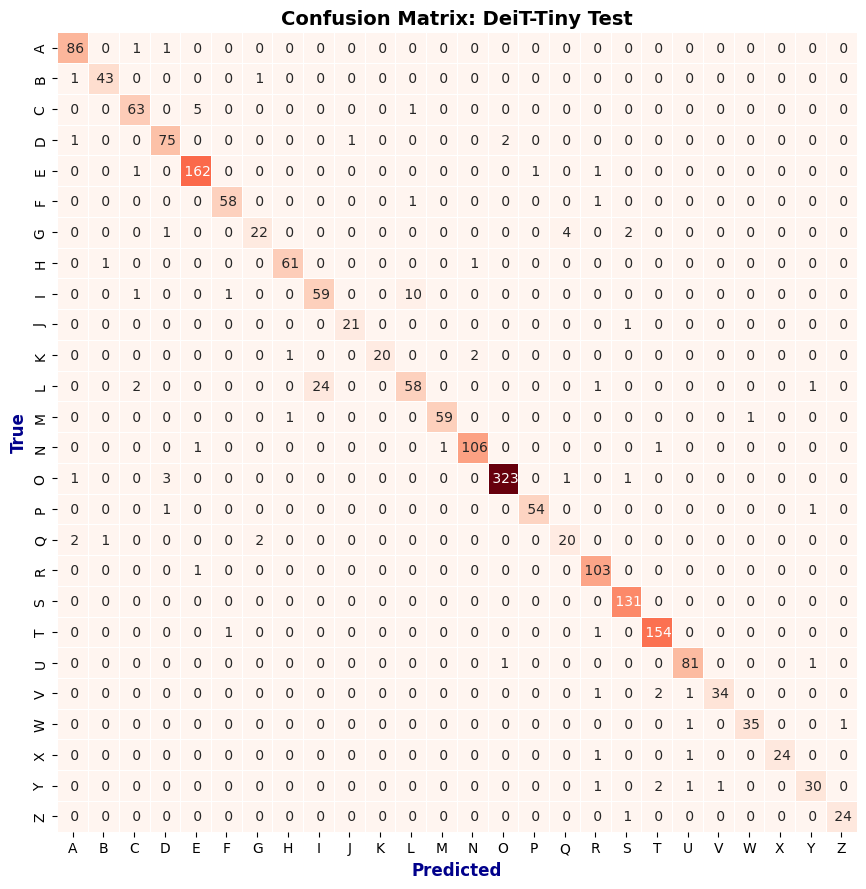

In [ ]:
# Reload best DeiT checkpoint, plot curves, run test inference, report accuracy
deit_model = load_checkpoint(deit_model, "best_deit.pth")

plot_training_curves(deit_history, title_prefix="DeiT-Tiny ")

# Run inference on the held-out test split
deit_test_probabilities = predict_probabilities(deit_model, deit_test_loader, desc="DeiT-Tiny inference")
deit_test_predictions = np.argmax(deit_test_probabilities, axis=1)

# Accuracy, classification report, and confusion matrix in one call
deit_test_accuracy = evaluate_and_report(y_test_true, deit_test_predictions, letter_classes, "Confusion Matrix: DeiT-Tiny Test")

## Ensemble Classifier (ResNet18 & DeiT-Tiny)

Blends the ResNet18 and DeiT-Tiny softmax probabilities into a single weighted ensemble. The blend weight is swept and selected on the validation split.:

DeiT-Tiny val inference: 100%|██████████| 16/16 [00:06<00:00,  2.58it/s]


Best blend weight (ResNet18 weight): 0.60 | Validation accuracy: 0.9633
Test Accuracy = 0.9613
              precision    recall  f1-score   support

           A     0.9667    0.9886    0.9775        88
           B     0.9556    0.9556    0.9556        45
           C     0.9559    0.9420    0.9489        69
           D     0.9146    0.9494    0.9317        79
           E     0.9704    0.9939    0.9820       165
           F     0.9831    0.9667    0.9748        60
           G     0.9231    0.8276    0.8727        29
           H     0.9683    0.9683    0.9683        63
           I     0.8429    0.8310    0.8369        71
           J     1.0000    0.9545    0.9767        22
           K     1.0000    0.9565    0.9778        23
           L     0.8471    0.8372    0.8421        86
           M     0.9833    0.9672    0.9752        61
           N     0.9727    0.9817    0.9772       109
           O     0.9939    0.9878    0.9909       329
           P     0.9821    0.9821    0.9

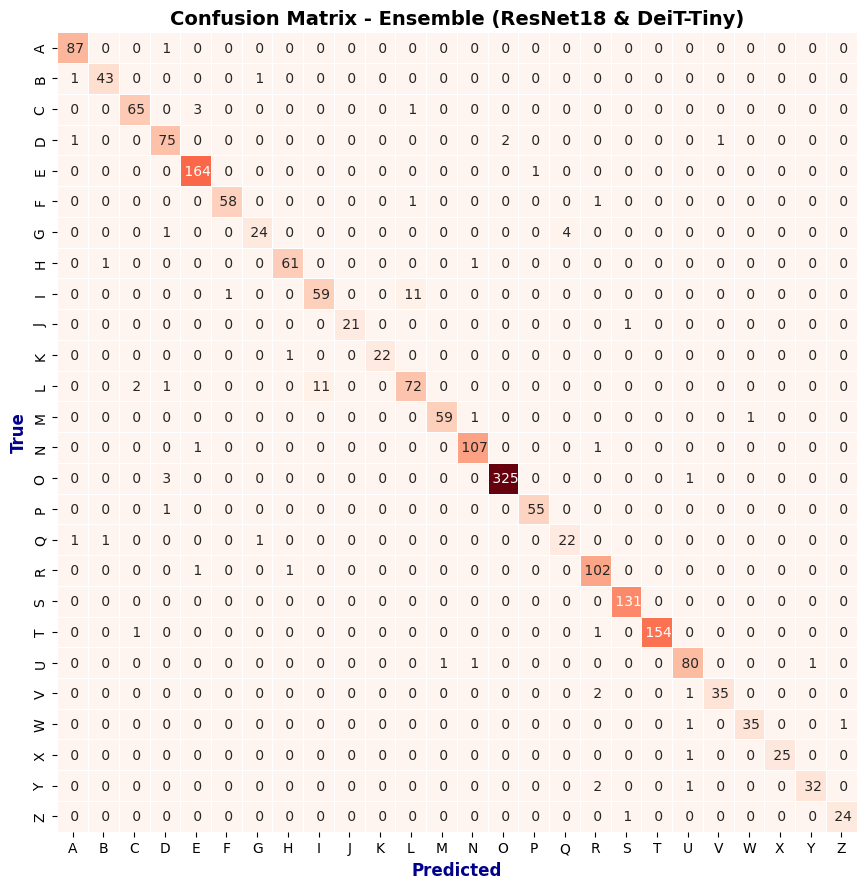

In [ ]:
# Sweep the blend weight on the validation split to find the best mix of the two models
resnet_val_probabilities = predict_probabilities(resnet_model, resnet_val_loader, desc="ResNet18 val inference")
deit_val_probabilities = predict_probabilities(deit_model, deit_val_loader, desc="DeiT-Tiny val inference")

# Try blend weights from 0.0 to 1.0 in steps of 0.05 (weight on ResNet18, rest to DeiT)
candidate_weights = np.arange(0.0, 1.01, 0.05)
# Pick the blend weight that gives the highest validation accuracy
candidate_accuracies = [accuracy_score(y_val_true, np.argmax(w * resnet_val_probabilities + (1 - w) * deit_val_probabilities, axis=1)) for w in candidate_weights]
best_blend_weight = candidate_weights[np.argmax(candidate_accuracies)]
best_val_accuracy = max(candidate_accuracies)

print(f"Best blend weight (ResNet18 weight): {best_blend_weight:.2f} | Validation accuracy: {best_val_accuracy:.4f}")

# Apply that single best weight to the already-computed test-set probabilities
ensemble_test_probabilities = best_blend_weight * resnet_test_probabilities + (1 - best_blend_weight) * deit_test_probabilities
ensemble_test_predictions = np.argmax(ensemble_test_probabilities, axis=1)

# Report ensemble accuracy, classification report, confusion matrix on the test set
ensemble_test_accuracy = evaluate_and_report(y_test_true, ensemble_test_predictions, letter_classes, "Confusion Matrix - Ensemble (ResNet18 & DeiT-Tiny)")

## CRNN Word Recognition (CTC)

Segmentation-free word recognition: replaces per-character contour segmentation with a CNN & BiLSTM trained via CTC loss, which learns the image-to-character alignment directly from full word images and labels.

In [ ]:
# Set CRNN hyperparams: image height 32px, max width 256px, 14 epochs, batch 512, lr 2e-3
IMG_HEIGHT = 32
MAX_IMG_WIDTH = 256
CTC_EPOCHS = 14
CTC_BATCH_SIZE = 512
CTC_LEARNING_RATE = 2e-3
CTC_PATIENCE = 3
CTC_MIN_DELTA = 1e-3
USE_AMP = torch.cuda.is_available()

# Load word image filenames & text labels from CSV
word_labels_csv_path = "/content/handwritten-words.csv"
word_images_dir = "/content/handwritten-words"

word_labels_df = pd.read_csv(word_labels_csv_path)
identity = word_labels_df["IDENTITY"].astype(str).str.strip()
word_labels_df["path"] = word_labels_df["FILENAME"].apply(lambda f: os.path.join(word_images_dir, f))
# Drop rows with missing labels or images that don't actually exist on disk
word_labels_df = word_labels_df[identity.notna() & (identity != "") & (identity.str.lower() != "nan") & word_labels_df["path"].apply(os.path.exists)]

# Build a character vocabulary from every character seen in the labels, index 0 is reserved for the CTC blank token
vocabulary_chars = sorted(set("".join(word_labels_df["IDENTITY"].astype(str).tolist())))
char_to_index = {char: i + 1 for i, char in enumerate(vocabulary_chars)}
index_to_char = {i: char for char, i in char_to_index.items()}
NUM_CHAR_CLASSES = len(char_to_index) + 1
BLANK_TOKEN_INDEX = 0

print(f"Vocabulary size (excl. blank): {len(char_to_index)}")
print(f"Chars: {''.join(vocabulary_chars)}")

# Split word data into train/val/test (80/10/10)
word_train_df, word_rest_df = tts(word_labels_df, test_size=0.2, random_state=RANDOM_SEED)
word_val_df, word_test_df = tts(word_rest_df, test_size=0.5, random_state=RANDOM_SEED)
print(f"Train/Val/Test sizes: {len(word_train_df)}/{len(word_val_df)}/{len(word_test_df)}")

Vocabulary size (excl. blank): 51
Chars:  '-ABCDEFGHIJKLMNOPQRSTUVWXYZ`abcdefghilmnoprstuvyz
Train/Val/Test sizes: 330390/41299/41299


In [ ]:
# Dataset class: reads a word image, resizes to fixed height (keeps aspect ratio, caps width)
class WordRecognitionDataset(Dataset):
    def __init__(self, dataframe, char_to_index, img_height=IMG_HEIGHT, max_width=MAX_IMG_WIDTH):
        """Store image paths, string labels, the character vocabulary, and target image dimensions."""
        self.paths = dataframe["path"].tolist()
        self.labels = dataframe["IDENTITY"].astype(str).tolist()
        self.char_to_index = char_to_index
        self.img_height = img_height
        self.max_width = max_width

    def __len__(self):
        return len(self.paths)

    # Normalizes pixel values to [-1, 1], returns (image, character-index target, raw label string)
    def _load_image(self, path):
        """Read a grayscale word image, resize it to a fixed height while preserving aspect ratio"""
        image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if image is None:
            raise ValueError(f"Cannot read {path}")
        height, width = image.shape
        new_width = max(1, int(width * (self.img_height / height)))
        new_width = min(new_width, self.max_width)
        image = cv2.resize(image, (new_width, self.img_height))
        image = image.astype(np.float32) / 255.0
        image = (image - 0.5) / 0.5
        return torch.from_numpy(image).unsqueeze(0)

    def __getitem__(self, idx):
        """Load one word image and encode its label as a sequence of character indices for CTC loss."""
        image = self._load_image(self.paths[idx])
        label_string = self.labels[idx]
        target = torch.tensor([self.char_to_index[c] for c in label_string], dtype=torch.long)
        return image, target, label_string

# Collate function: pads each batch's images to that batch's own max width, concatenates targets
def ctc_collate_fn(batch):
    """Pads a batch's images to its own max width and concatenates the CTC targets."""
    images, targets, label_strings = zip(*batch)
    widths = [image.shape[-1] for image in images]
    max_width = max(widths)

    padded_images = torch.zeros(len(images), 1, IMG_HEIGHT, max_width)
    for i, image in enumerate(images):
        padded_images[i, :, :, :image.shape[-1]] = image

    target_lengths = torch.tensor([len(t) for t in targets], dtype=torch.long)
    concatenated_targets = torch.cat(targets)

    input_lengths = torch.tensor([w // 4 for w in widths], dtype=torch.long)

    return padded_images, concatenated_targets, target_lengths, input_lengths, label_strings


word_train_dataset = WordRecognitionDataset(word_train_df, char_to_index)
word_val_dataset = WordRecognitionDataset(word_val_df, char_to_index)
word_test_dataset = WordRecognitionDataset(word_test_df, char_to_index)

word_train_loader = DataLoader(word_train_dataset, batch_size=CTC_BATCH_SIZE, shuffle=True, collate_fn=ctc_collate_fn, num_workers=num_workers, pin_memory=True)
word_val_loader = DataLoader(word_val_dataset, batch_size=CTC_BATCH_SIZE, shuffle=False, collate_fn=ctc_collate_fn, num_workers=num_workers, pin_memory=True)
word_test_loader = DataLoader(word_test_dataset, batch_size=CTC_BATCH_SIZE, shuffle=False, collate_fn=ctc_collate_fn, num_workers=num_workers, pin_memory=True)

In [ ]:
# CRNN model: conv layers shrink height 8x while keeping width (so width is equal to time steps)
class CRNN(nn.Module):
    """CNN feature extractor -> BiLSTM -> per-timestep character logits, trained with CTC."""

    def __init__(self, num_classes, img_height=IMG_HEIGHT):
        """Build the conv stack (downsamples height by 8x while preserving width resolution),
        the bidirectional LSTM that reads the resulting feature sequence, and the final
        per-timestep character classifier."""
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d((2, 1), (2, 1)),

            nn.Conv2d(256, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(),
        )
        cnn_output_height = img_height // 8
        # Reshape conv output into a left-to-right sequence, feed through a 2-layer BiLSTM
        self.rnn = nn.LSTM(512 * cnn_output_height, 256, num_layers=2, bidirectional=True, batch_first=True, dropout=0.2)
        # Final linear layer outputs per-timestep character scores (log-softmax, CTC-ready format)
        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        """Run the conv stack, reshape the feature map into a left-to-right sequence, and return
        per-timestep log-probabilities in the (T, B, C) layout CTCLoss expects."""
        features = self.cnn(x)
        b, c, h, w = features.shape
        features = features.permute(0, 3, 1, 2).reshape(b, w, c * h)
        rnn_output, _ = self.rnn(features)
        logits = self.fc(rnn_output)
        return logits.permute(1, 0, 2).log_softmax(2)

crnn_model = CRNN(NUM_CHAR_CLASSES).to(DEVICE)
ctc_loss_fn = nn.CTCLoss(blank=BLANK_TOKEN_INDEX, zero_infinity=True)
ctc_optimizer = optim.Adam(crnn_model.parameters(), lr=CTC_LEARNING_RATE, weight_decay=1e-4)
ctc_scheduler = OneCycleLR(ctc_optimizer, max_lr=CTC_LEARNING_RATE, total_steps=len(word_train_loader) * CTC_EPOCHS + 1, pct_start=0.3)
# Uses the CTC-specific patience/min_delta for early stopping
crnn_early_stopping = EarlyStopping(patience=CTC_PATIENCE, min_delta=CTC_MIN_DELTA, checkpoint_path="best_crnn.pth")

In [ ]:
# Greedy CTC decode: take the highest-probability character at each timestep
def ctc_greedy_decode(logits, index_to_char, blank_index=BLANK_TOKEN_INDEX):
    """Converts (W', B, num_classes) log-probs into decoded strings via greedy CTC decoding."""
    predicted_indices = logits.argmax(dim=2).transpose(0, 1).cpu().numpy()
    decoded_strings = []
    for sequence in predicted_indices:
        characters = []
        previous_index = blank_index
        for index in sequence:
            # Collapse repeated characters and drop blank tokens to get the final predicted string
            if index != previous_index and index != blank_index:
                characters.append(index_to_char[index])
            previous_index = index
        decoded_strings.append("".join(characters))
    return decoded_strings

In [ ]:
# Train using mixed precision (fp16) for speed, but keep the CTC loss computation in fp32
amp_scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

def train_epoch_crnn(model, dataloader, loss_fn, optimizer, scheduler=None):
    """Runs one training epoch over the CRNN and returns the average CTC loss."""
    model.train()
    total_loss = 0
    for images, char_targets, target_lengths, input_lengths, _ in dataloader:
        images = images.to(DEVICE, non_blocking=True)
        char_targets = char_targets.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type="cuda", enabled=USE_AMP):
            logits = model(images)
        # Cast back to fp32 before the loss, since CTCLoss needs full-precision log-probs
        logits = logits.float()
        loss = loss_fn(logits, char_targets, input_lengths, target_lengths)

        # Clip gradients after unscaling them, step the optimizer, update the LR scheduler
        amp_scaler.scale(loss).backward()
        amp_scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        amp_scaler.step(optimizer)
        amp_scaler.update()
        if scheduler:
            scheduler.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)

# Validation pass: track loss, character error rate (CER), and exact-match word accuracy
def evaluate_epoch_crnn(model, dataloader, loss_fn, index_to_char):
    """Runs one validation pass over the CRNN: loss, character error rate, and exact-match word accuracy."""
    model.eval()
    total_loss, total_cer, exact_match_count, word_count = 0, 0, 0, 0
    with torch.inference_mode():
        for images, char_targets, target_lengths, input_lengths, label_strings in dataloader:
            images = images.to(DEVICE, non_blocking=True)
            char_targets = char_targets.to(DEVICE, non_blocking=True)
            with torch.autocast(device_type="cuda", enabled=USE_AMP):
                logits = model(images)
            logits = logits.float()
            loss = loss_fn(logits, char_targets, input_lengths, target_lengths)
            total_loss += loss.item()

            # Decode predictions and score them against ground truth, word by word
            predictions = ctc_greedy_decode(logits, index_to_char)
            for prediction, truth in zip(predictions, label_strings):
                total_cer += jiwer.cer(truth, prediction)
                exact_match_count += int(prediction == truth)
                word_count += 1
    return total_loss / len(dataloader), total_cer / word_count, exact_match_count / word_count


crnn_history = {"train_loss": [], "val_loss": [], "val_cer": [], "val_accuracy": []}

for epoch in tqdm(range(CTC_EPOCHS), desc="Training CRNN"):
    train_loss = train_epoch_crnn(crnn_model, word_train_loader, ctc_loss_fn, ctc_optimizer, ctc_scheduler)
    val_loss, val_cer, val_accuracy = evaluate_epoch_crnn(crnn_model, word_val_loader, ctc_loss_fn, index_to_char)

    print(f"Epoch {epoch+1}: Train Loss {train_loss:.4f}, "
          f"Val Loss {val_loss:.4f}, Val CER {val_cer:.4f}, Val Word Acc {val_accuracy:.4f}")

    # Check for improvement and checkpoint / flag early stopping accordingly
    crnn_early_stopping(val_loss, crnn_model)
    if crnn_early_stopping.early_stop:
        print("Early stopping triggered.")
        break

    crnn_history["train_loss"].append(train_loss)
    crnn_history["val_loss"].append(val_loss)
    crnn_history["val_cer"].append(val_cer)
    crnn_history["val_accuracy"].append(val_accuracy)

/tmp/ipykernel_1565/1290818334.py:2: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  amp_scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
Training CRNN:   0%|          | 0/14 [00:00<?, ?it/s]/tmp/ipykernel_1565/1290818334.py:26: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()
Training CRNN:   7%|▋         | 1/14 [05:04<1:05:59, 304.59s/it]

Epoch 1: Train Loss 3.0639, Val Loss 0.5350, Val CER 0.1779, Val Word Acc 0.3414


Training CRNN:  14%|█▍        | 2/14 [10:18<1:01:58, 309.84s/it]

Epoch 2: Train Loss 0.2814, Val Loss 0.2738, Val CER 0.0672, Val Word Acc 0.7413


Training CRNN:  21%|██▏       | 3/14 [15:30<57:03, 311.18s/it]  

...

Epoch 12: Train Loss 0.1414, Val Loss 0.1678, Val CER 0.0390, Val Word Acc 0.8535


Training CRNN:  93%|█████████▎| 13/14 [1:07:05<05:08, 308.56s/it]

Epoch 13: Train Loss 0.1259, Val Loss 0.1680, Val CER 0.0386, Val Word Acc 0.8553


Training CRNN: 100%|██████████| 14/14 [1:12:13<00:00, 309.55s/it]

Epoch 14: Train Loss 0.1143, Val Loss 0.1686, Val CER 0.0386, Val Word Acc 0.8554


## End-to-End Evaluation

Reloads the best CRNN checkpoint and runs it once over the held-out test split, reporting
exact-match word accuracy and mean character error rate (CER), then plots the training curves
recorded during the CRNN training loop above.

CRNN test inference: 100%|██████████| 81/81 [00:28<00:00,  2.87it/s]


Word accuracy: 85.21% (CER: 0.040)


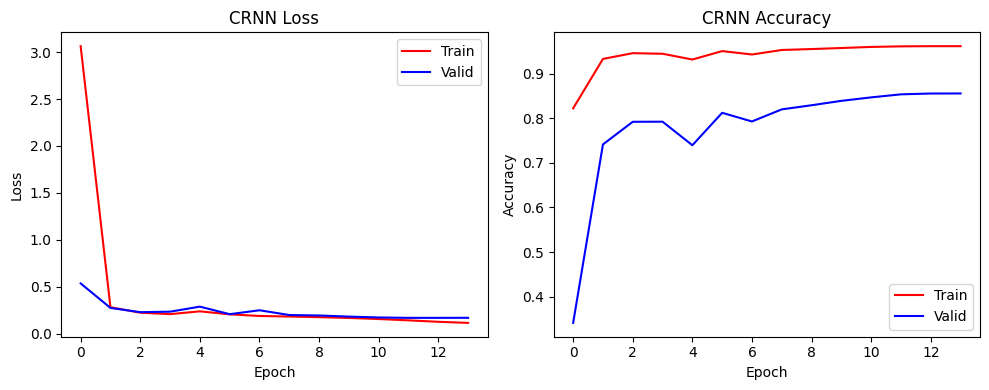

In [ ]:
# Reload the best CRNN checkpoint
crnn_model = load_checkpoint(crnn_model, "best_crnn.pth")

predicted_words, ground_truth_words = [], []
correct_word_count, total_word_count = 0, 0

# Run CRNN once over the held-out test set, decoding each predicted word
crnn_model.eval()
with torch.inference_mode():
    for images, char_targets, target_lengths, input_lengths, label_strings in tqdm(word_test_loader, desc="CRNN test inference"):
        images = images.to(DEVICE)
        logits = crnn_model(images)
        predictions = ctc_greedy_decode(logits, index_to_char)

        for prediction, ground_truth in zip(predictions, label_strings):
            total_word_count += 1
            # Compare predictions to ground truth case-insensitively to get word accuracy
            correct_word_count += int(prediction.lower() == ground_truth.lower())

            predicted_words.append(prediction.lower())
            ground_truth_words.append(ground_truth.lower())

# Compute average character error rate (CER) across all test words
mean_cer = np.mean([jiwer.cer(t, p) for p, t in zip(predicted_words, ground_truth_words)])

# Print final word accuracy % and mean CER
print(f"Word accuracy: {correct_word_count / total_word_count * 100:.2f}% (CER: {mean_cer:.3f})")

# Plot the CRNN's training curves (loss, accuracy/CER over epochs)
plot_training_curves({"train_loss": crnn_history["train_loss"], "val_loss": crnn_history["val_loss"], "train_accuracy": [1 - c for c in crnn_history["val_cer"]], "val_accuracy": crnn_history["val_accuracy"]}, title_prefix="CRNN ")